# Week 3 Code:
Efficient frontier(part 1)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
ret = pd.read_csv("Untitled Folder/data3_industry_30_vw_monthly.csv", header=0, index_col=0)
ret = ret/100
ret.index = pd.to_datetime(ret.index,format = "%Y%m").to_period("M")
ret.head(3)

,Food,Beer,Smoke,Games,Books,Hshld,Clths,Hlth,Chems,Txtls,...,Telcm,Servs,BusEq,Paper,Trans,Whlsl,Rtail,Meals,Fin,Other
1926-07,0.0056,-0.0519,0.0129,0.0293,0.1097,-0.0048,0.0808,0.0177,0.0814,0.0039,...,0.0083,0.0922,0.0206,0.0770,0.0191,-0.2379,0.0007,0.0187,-0.0002,0.0520
1926-08,0.0259,0.2703,0.0650,0.0055,0.1001,-0.0358,-0.0251,0.0425,0.0550,0.0797,...,0.0217,0.0202,0.0439,-0.0238,0.0485,0.0539,-0.0075,-0.0013,0.0447,0.0676
1926-09,0.0116,0.0402,0.0126,0.0658,-0.0099,0.0073,-0.0051,0.0069,0.0533,0.0230,...,0.0241,0.0225,0.0019,-0.0554,0.0007,-0.0787,0.0025,-0.0056,-0.0161,-0.0386


In [16]:
ret.columns

Index(['Food ', 'Beer ', 'Smoke', 'Games', 'Books', 'Hshld', 'Clths', 'Hlth ',
       'Chems', 'Txtls', 'Cnstr', 'Steel', 'FabPr', 'ElcEq', 'Autos', 'Carry',
       'Mines', 'Coal ', 'Oil  ', 'Util ', 'Telcm', 'Servs', 'BusEq', 'Paper',
       'Trans', 'Whlsl', 'Rtail', 'Meals', 'Fin  ', 'Other'],
      dtype='object')

In [19]:
ret.columns = ret.columns.str.strip()
ret.columns

Index(['Food', 'Beer', 'Smoke', 'Games', 'Books', 'Hshld', 'Clths', 'Hlth',
       'Chems', 'Txtls', 'Cnstr', 'Steel', 'FabPr', 'ElcEq', 'Autos', 'Carry',
       'Mines', 'Coal', 'Oil', 'Util', 'Telcm', 'Servs', 'BusEq', 'Paper',
       'Trans', 'Whlsl', 'Rtail', 'Meals', 'Fin', 'Other'],
      dtype='object')

<Axes: >

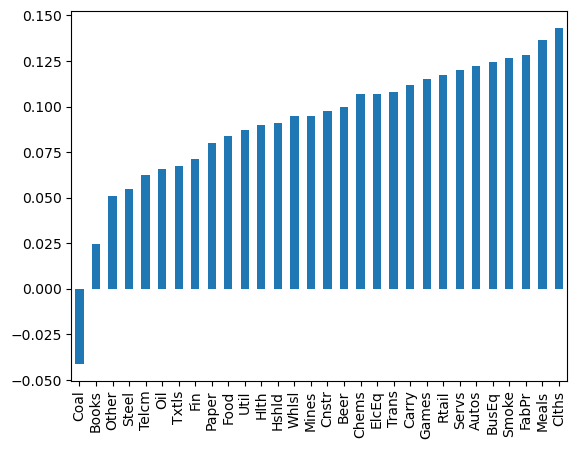

In [31]:
n_year = ret["2002":].shape[0]/12
eret = ((1+ret["2002":]).prod())**(1/n_year)-1
eret.sort_values().plot.bar(fig=(8,3))

In [35]:
cov = ret["2002":].cov() * 12
cov.head()

,Food,Beer,Smoke,Games,Books,Hshld,Clths,Hlth,Chems,Txtls,...,Telcm,Servs,BusEq,Paper,Trans,Whlsl,Rtail,Meals,Fin,Other
Food,0.014584,0.011444,0.014720,0.018695,0.016820,0.011146,0.014478,0.010235,0.016717,0.021528,...,0.014347,0.013508,0.014819,0.013971,0.014024,0.014935,0.011871,0.012974,0.015314,0.013737
Beer,0.011444,0.017883,0.013826,0.013924,0.013194,0.011987,0.011975,0.010005,0.013547,0.016035,...,0.012279,0.010940,0.012070,0.012822,0.012322,0.012130,0.010532,0.011665,0.013083,0.012758
Smoke,0.014720,0.013826,0.045972,0.017741,0.017690,0.012106,0.013011,0.011872,0.014757,0.018106,...,0.016463,0.013424,0.016980,0.014890,0.014134,0.016097,0.009509,0.013073,0.015603,0.014752
Games,0.018695,0.013924,0.017741,0.064248,0.041778,0.018038,0.038500,0.020632,0.040233,0.058355,...,0.029437,0.035113,0.039236,0.031388,0.033720,0.033009,0.028029,0.028991,0.038456,0.031805
Books,0.016820,0.013194,0.017690,0.041778,0.049515,0.016983,0.031348,0.018341,0.034198,0.055385,...,0.027059,0.026463,0.029642,0.029028,0.029798,0.030523,0.022370,0.022519,0.035245,0.028305


In [37]:
def port_ret(weights, ereturns):
    """
    weights + assets' exp returns --> portfolio return
    """
    return weights.T@ereturns

In [39]:
def port_vol(weights, covmat):
    """
    weights + covariance matrix --> portfolio volatility
    """
    return (weights.T@covmat@weights)**0.5

In [41]:
l = ["Food", "Beer", "Smoke", "Games"]
eret[l]

Food     0.083784
Beer     0.099543
Smoke    0.126471
Games    0.115264
dtype: float64

In [43]:
cov.loc[l,l]

,Food,Beer,Smoke,Games
Food,0.014584,0.011444,0.014720,0.018695
Beer,0.011444,0.017883,0.013826,0.013924
Smoke,0.014720,0.013826,0.045972,0.017741
Games,0.018695,0.013924,0.017741,0.064248


In [45]:
w = np.repeat(.25,4)
w

array([0.25, 0.25, 0.25, 0.25])

In [47]:
port_ret(w, eret[l])

0.10626554205342381

In [49]:
port_vol(w, cov.loc[l,l])

0.1421674560754436

## The case of two assets:

In [53]:
n_points = 21
weights = [np.array([w, 1-w]) for w in np.linspace(0,1,n_points)]
weights

[array([0., 1.]),
 array([0.05, 0.95]),
 array([0.1, 0.9]),
 array([0.15, 0.85]),
 array([0.2, 0.8]),
 array([0.25, 0.75]),
 array([0.3, 0.7]),
 array([0.35, 0.65]),
 array([0.4, 0.6]),
 array([0.45, 0.55]),
 array([0.5, 0.5]),
 array([0.55, 0.45]),
 array([0.6, 0.4]),
 array([0.65, 0.35]),
 array([0.7, 0.3]),
 array([0.75, 0.25]),
 array([0.8, 0.2]),
 array([0.85, 0.15]),
 array([0.9, 0.1]),
 array([0.95, 0.05]),
 array([1., 0.])]

In [55]:
l = ["Games", "Beer"]  
ereturns = [port_ret(w, eret[l]) for w in weights]
vols = [port_vol(w, cov.loc[l,l]) for w in weights]

In [57]:
ef = pd.DataFrame({"Returns": ereturns,
                  "Volatility": vols})
ef.head()

,Returns,Volatility
0,0.099543,0.133728
1,0.100329,0.132751
2,0.101115,0.132793
3,0.101901,0.133853
4,0.102687,0.135907


<Axes: xlabel='Volatility', ylabel='Returns'>

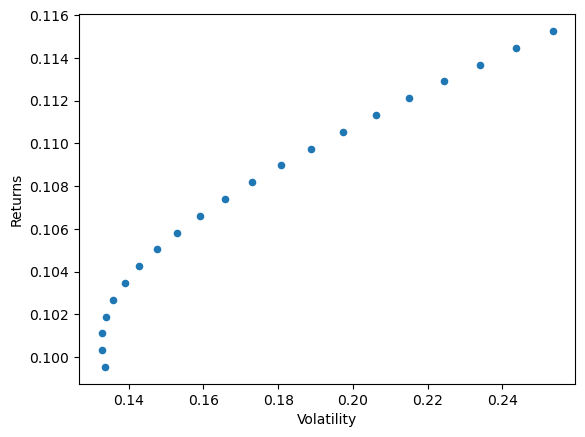

In [59]:
ef.plot.scatter(x = "Volatility", y = "Returns")

<Axes: xlabel='Volatility'>

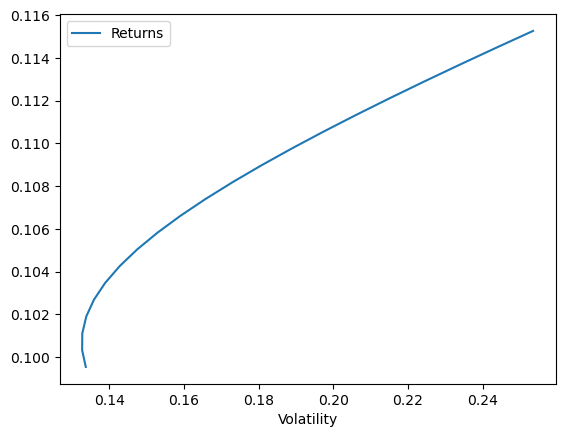

In [61]:
ef.plot.line(x = "Volatility", y = "Returns")